# Handwritten Digits — CSCI 580

Train an MLP on MNIST and evaluate on a custom set of class-collected handwritten digits.
A unified preprocessor (threshold → crop to digit → scale → center-pad) makes both
distributions look the same to the model.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from tqdm.notebook import tqdm


In [3]:
# Globals
SEED        = 42
IMG_SIZE    = 28
NUM_CLASSES = 10
N_VAL       = 5000
BATCH_TRAIN = 64
BATCH_EVAL  = 128

DATA_PATH  = str(Path.home() / 'Documents/dev/school/Handwritten-Digits-Spring-2026/digits')
MNIST_ROOT = str(Path.home() / '.cache/mnist')


## TrainingMonitor

In [4]:
class TrainingMonitor:
    """Collects per-batch training metrics, per-epoch validation metrics, and
    final-eval predictions; renders all diagnostic plots on `plt()`.

    Designed so the training loop stays clean — a single object owns all
    bookkeeping, and a future hyperparameter sweep can hold a list of monitors
    (one per run) without changing the training code.

    Usage:
        m = TrainingMonitor(name='DigitMLP')
        # during training: m.log_batch_train(loss, acc) / m.log_epoch_val(vl, va)
        m.add_eval('custom', y_true, y_pred, groups=custom_groups)
        m.add_eval('mnist_test', y_true, y_pred, with_confusion=False)
        m.plt()
    """

    def __init__(self, name=''):
        self.name = name
        # Per-batch training metrics (1 entry per batch).
        self.batch_train_loss = []
        self.batch_train_acc  = []
        # Per-epoch validation metrics (1 entry per epoch).
        self.epoch_val_loss   = []
        self.epoch_val_acc    = []
        # Batch index at the end of each epoch — x-coordinate for val markers.
        self.epoch_boundaries = []
        # Final-eval predictions, keyed by name.
        self.evals = {}

    # ---- ingestion -------------------------------------------------------
    def log_batch_train(self, loss, acc):
        self.batch_train_loss.append(float(loss))
        self.batch_train_acc.append(float(acc))

    def log_epoch_val(self, loss, acc):
        self.epoch_val_loss.append(float(loss))
        self.epoch_val_acc.append(float(acc))
        self.epoch_boundaries.append(len(self.batch_train_loss))

    def add_eval(self, name, y_true, y_pred, groups=None, with_confusion=True):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        self.evals[name] = {
            'y_true':         y_true,
            'y_pred':         y_pred,
            'groups':         np.asarray(groups) if groups is not None else None,
            'accuracy':       accuracy_score(y_true, y_pred),
            'macro_f1':       f1_score(y_true, y_pred, average='macro'),
            'with_confusion': with_confusion,
        }

    # ---- rendering -------------------------------------------------------
    def _print_summary(self):
        if not self.evals:
            return
        print('Final metrics:')
        width = max(len(n) for n in self.evals)
        for name, e in self.evals.items():
            print(f"  {name:>{width}}:  accuracy={e['accuracy']:.3f}   macro-F1={e['macro_f1']:.3f}")

    def _plot_curves(self):
        if not self.batch_train_loss:
            return
        n = len(self.batch_train_loss)
        x = np.arange(1, n + 1)
        win = max(1, min(50, n // 20))
        smooth_loss = pd.Series(self.batch_train_loss).rolling(win, min_periods=1).mean()
        smooth_acc  = pd.Series(self.batch_train_acc ).rolling(win, min_periods=1).mean()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        title = self.name or 'Training'
        fig.suptitle(title, fontsize=11)

        axes[0].plot(x, self.batch_train_loss, color='tab:blue', alpha=0.2)
        axes[0].plot(x, smooth_loss, color='tab:blue', linewidth=1.5,
                     label=f'train (smoothed, w={win})')
        if self.epoch_val_loss:
            axes[0].plot(self.epoch_boundaries, self.epoch_val_loss, 'o-',
                         color='tab:red', markersize=6, label='val (per epoch)')
        axes[0].set_xlabel('Batch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(x, self.batch_train_acc, color='tab:blue', alpha=0.2)
        axes[1].plot(x, smooth_acc, color='tab:blue', linewidth=1.5,
                     label=f'train (smoothed, w={win})')
        if self.epoch_val_acc:
            axes[1].plot(self.epoch_boundaries, self.epoch_val_acc, 'o-',
                         color='tab:red', markersize=6, label='val (per epoch)')
        axes[1].set_xlabel('Batch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Accuracy')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    def _plot_confusion(self, name, e):
        cm = confusion_matrix(e['y_true'], e['y_pred'], labels=list(range(NUM_CLASSES)))
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
                    cbar=False, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f"Confusion matrix — {name}  "
                     f"(acc={e['accuracy']:.3f}, F1={e['macro_f1']:.3f})")
        plt.tight_layout()
        plt.show()

    def _plot_groups(self, name, e):
        df = pd.DataFrame({'group': e['groups'], 'correct': e['y_true'] == e['y_pred']})
        per = (df.groupby('group')['correct']
                 .agg(['mean', 'count'])
                 .reset_index()
                 .rename(columns={'mean': 'accuracy', 'count': 'n'})
                 .sort_values('group'))

        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(per['group'].astype(str), per['accuracy'], color='tab:blue', alpha=0.8)
        for bar, n in zip(bars, per['n']):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'n={n}', ha='center', fontsize=9)
        overall = e['accuracy']
        ax.axhline(overall, ls='--', color='tab:red', alpha=0.7,
                   label=f'overall = {overall:.3f}')
        ax.set_xlabel('Group')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1.08)
        ax.set_title(f'Per-group accuracy — {name}')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    def plt(self):
        self._print_summary()
        self._plot_curves()
        for name, e in self.evals.items():
            if e['with_confusion']:
                self._plot_confusion(name, e)
        for name, e in self.evals.items():
            if e['groups'] is not None:
                self._plot_groups(name, e)


## Data

In [ ]:
IMG_EXTS = {'.png', '.jpg', '.jpeg'}


class HandwrittenDigits(Dataset):
    """Class-collected digits laid out as <digit>-<group>-<member>.png in DATA_PATH.

    `samples` is a list of (path, label, group, member) tuples in sorted-filename
    order; `groups` exposes group ids aligned with that order so per-group
    accuracy can be computed against a non-shuffled DataLoader's predictions.
    """
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.samples = []
        for p in sorted(self.data_dir.iterdir()):
            if p.suffix.lower() not in IMG_EXTS:
                continue
            parts = p.stem.split('-')
            label  = int(parts[0])
            group  = int(parts[1]) if len(parts) >= 2 else None
            member = int(parts[2]) if len(parts) >= 3 else None
            self.samples.append((p, label, group, member))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, _, _ = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

    @property
    def groups(self):
        return [s[2] for s in self.samples]


class TransformSubset(Dataset):
    """Wrap a Subset and apply a transform at __getitem__ time.

    Lets train/val splits of the same MNIST download use different transforms
    (augmented vs eval), avoiding a second download/load.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


class CenterCropToContent:
    """Threshold-binarize, crop to digit bbox, scale-preserving resize, center-pad to size.

    Auto-inverts dark-on-light images so the digit is always bright on dark bg
    (matching MNIST). Applied uniformly to MNIST and custom data so both
    distributions look the same to the model.
    """
    def __init__(self, size=IMG_SIZE, threshold=0.3, margin=2):
        self.size = size
        self.threshold = threshold
        self.margin = margin

    def __call__(self, img):
        # 1: Convert to Grayscale
        arr = np.asarray(img.convert('L'), dtype=np.float32) / 255.0

        # 2: Bright on dark
        if arr.mean() > 0.5:
            arr = 1.0 - arr

        # 3: Identify digit (anything > threshold)
        mask = arr > self.threshold
        if not mask.any():
            return Image.fromarray(np.zeros((self.size, self.size), dtype=np.uint8))

        # 4: Crop to bounding box
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max() + 1
        x0, x1 = xs.min(), xs.max() + 1
        digit = (arr[y0:y1, x0:x1] * 255).astype(np.uint8)

        # 5: Resize to desired size
        h, w = digit.shape
        target = self.size - 2 * self.margin
        scale = target / max(h, w)
        new_h, new_w = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
        digit_img = Image.fromarray(digit).resize((new_w, new_h), Image.BILINEAR)

        # 6: Place isolated digit on black canvas
        canvas = Image.new('L', (self.size, self.size), 0)
        canvas.paste(digit_img, ((self.size - new_w) // 2, (self.size - new_h) // 2))
        return canvas


In [ ]:
# Load MNIST once with no transform; apply train/eval transforms after the split
# via TransformSubset. Avoids the double-download workaround.
mnist_train_transform = transforms.Compose([
    CenterCropToContent(IMG_SIZE),
    transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.85, 1.15), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.RadomErasing(p=0.25, scale=(0.02, 0.1), value=0),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_eval_transform = transforms.Compose([
    CenterCropToContent(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_full = datasets.MNIST(root=MNIST_ROOT, train=True,  download=True, transform=None)
mnist_test = datasets.MNIST(root=MNIST_ROOT, train=False, download=True,
                            transform=mnist_eval_transform)

torch.manual_seed(SEED)
n_train = len(mnist_full) - N_VAL
train_subset, val_subset = random_split(mnist_full, [n_train, N_VAL])

train_set = TransformSubset(train_subset, mnist_train_transform)
val_set   = TransformSubset(val_subset,   mnist_eval_transform)

# num_workers=0: CenterCropToContent is defined in this notebook, and macOS
# spawn-mode multiprocessing can't re-import classes from __main__.
train_loader      = DataLoader(train_set, batch_size=BATCH_TRAIN, shuffle=True, num_workers=0)
val_loader        = DataLoader(val_set,   batch_size=BATCH_EVAL,                 num_workers=0)
mnist_test_loader = DataLoader(mnist_test, batch_size=BATCH_EVAL,                num_workers=0)


In [7]:
custom_transform = transforms.Compose([
    CenterCropToContent(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# shuffle=False so iteration order matches custom_dataset.samples — letting
# us align predictions with group ids without bookkeeping.
custom_dataset = HandwrittenDigits(DATA_PATH, transform=custom_transform)
custom_loader  = DataLoader(custom_dataset, batch_size=BATCH_EVAL, shuffle=False)
print(f"Custom dataset: {len(custom_dataset)} samples")


Custom dataset: 280 samples


## Model

In [ ]:
ACTIVATIONS = {
    'relu':       nn.ReLU,
    'gelu':       nn.GELU,
    'tanh':       nn.Tanh,
    'leaky_relu': nn.LeakyReLU,
    'sigmoid':    nn.Sigmoid,
}


class DigitMLP(nn.Module):
    """28×28 → ... → 10 MLP for digit classification.

    Input/output sizing is fixed but depth, width, dropout, activation,
    and batchnorm are configurable so each experiment cell can vary one knob.
    """
    def __init__(self, hidden_sizes=(256, 128), dropout=0.3,
                 activation='relu', use_batchnorm=True):
        super().__init__()
        act = ACTIVATIONS[activation]
        layers, prev = [], IMG_SIZE * IMG_SIZE
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, NUM_CLASSES))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.flatten(1))


## Training & validation

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device, monitor):
    model.train()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        acc = (logits.argmax(1) == labels).float().mean().item()
        monitor.log_batch_train(loss.item(), acc)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def train(model, monitor, lr, epochs):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    desc = f'{monitor.name}: Epoch' if monitor.name else 'Epoch'
    for _ in tqdm(range(epochs), desc=desc):
        train_epoch(model, train_loader, optimizer, criterion, device, monitor)
        vl, va = evaluate(model, val_loader, criterion, device)
        monitor.log_epoch_val(vl, va)


def validate(model, monitor):
    """Final eval on MNIST test (metrics only) and the custom dataset
    (metrics + confusion matrix + per-group accuracy). Also attaches the
    trained model to the monitor so the live demo can find it later."""
    monitor.model = model
    y_true, y_pred = get_predictions(model, mnist_test_loader, device)
    monitor.add_eval('mnist_test', y_true, y_pred, with_confusion=False)

    y_true, y_pred = get_predictions(model, custom_loader, device)
    monitor.add_eval('custom', y_true, y_pred, groups=custom_dataset.groups)
    save_monitor(monitor)


def pick_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


## Experiments

Each experiment is a self-contained cell. The pattern is always the same:

1. Seed for reproducibility.
2. Make a fresh `TrainingMonitor` (the `name` shows up on the plots).
3. Initialize `DigitMLP` with the configuration to test.
4. `train(...)` — per-batch and per-epoch metrics go to the monitor.
5. `validate(...)` — final eval on MNIST test and the custom dataset.
6. `monitor.plt()` — renders summary, training curves, confusion matrix, per-group accuracy.

To compare runs, copy a cell, rename the monitor, and tweak parameters.


In [10]:
device = pick_device()
criterion = nn.CrossEntropyLoss()
print(f'Using device: {device}')


Using device: mps


## Persistence

Trained monitors (with their model attached) are pickled to `~/.cache/csci580_runs/<name>.pt`. On startup we lazy-load every cached run into `monitors`. Each experiment cell becomes idempotent — running it again is a no-op + re-render unless the run isn't cached.

**To force a retrain**: `del monitors['<name>']` before running the cell, or set `FORCE_RETRAIN = True` to wipe everything.


In [11]:
RUNS_DIR = Path.home() / '.cache' / 'csci580_runs'
RUNS_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False  # flip to True to wipe the cache and retrain everything


def save_monitor(monitor):
    torch.save(monitor, RUNS_DIR / f'{monitor.name}.pt')


def load_monitors():
    out = {}
    for path in sorted(RUNS_DIR.glob('*.pt')):
        try:
            m = torch.load(path, map_location=device, weights_only=False)
            out[m.name] = m
        except Exception as e:
            print(f'Skip {path.name}: {e}')
    return out


if FORCE_RETRAIN:
    for p in RUNS_DIR.glob('*.pt'):
        p.unlink()

monitors = load_monitors()
print(f'Loaded {len(monitors)} cached monitor(s): {sorted(monitors)}')


Loaded 9 cached monitor(s): ['128', '256', '256 d=0.5', '256-128', '256-128 lr=5e-4', '256-256', '32-32-32-32', '512', '64-64']


### Experiment #1

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(256, 128)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.981   macro-F1=0.981
      custom:  accuracy=0.896   macro-F1=0.902


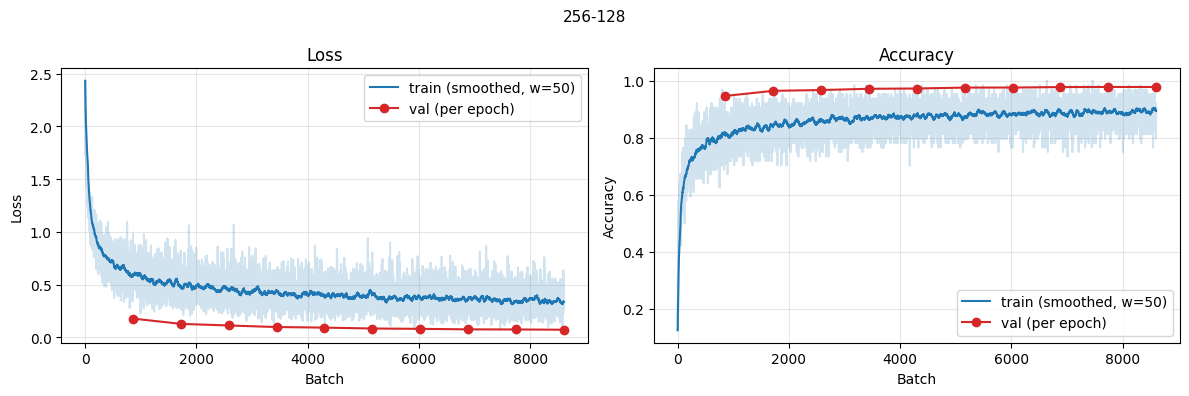

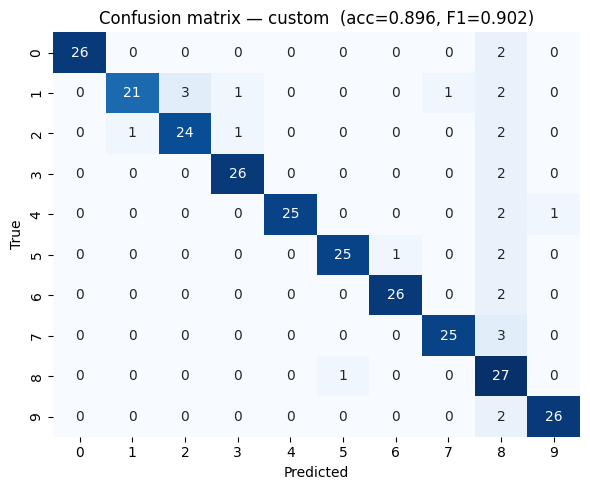

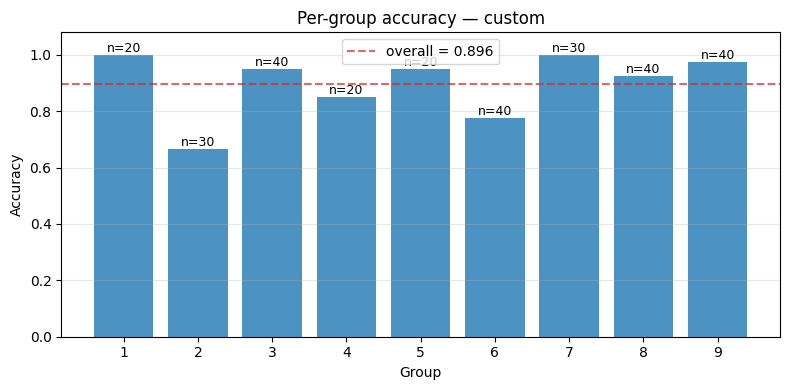

In [12]:
NAME = '256-128'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(256, 128), dropout=0.3, activation='relu').to(device)
    train(model, monitor, lr=1e-3, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #2

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(256,)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.975   macro-F1=0.975
      custom:  accuracy=0.939   macro-F1=0.940


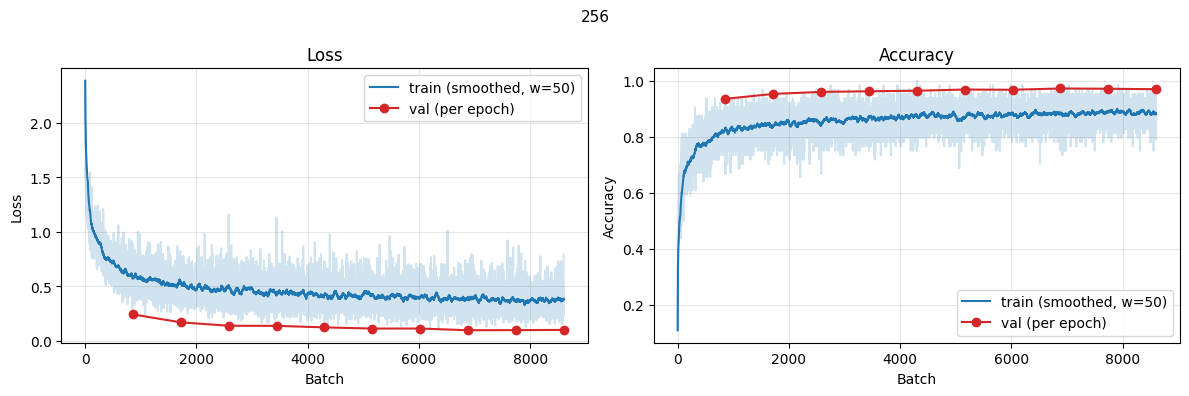

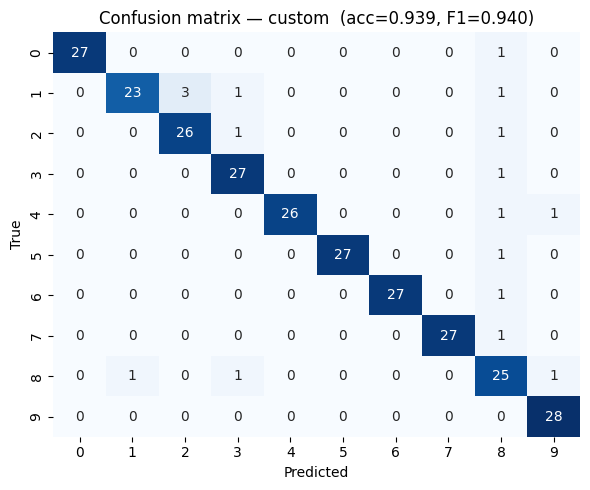

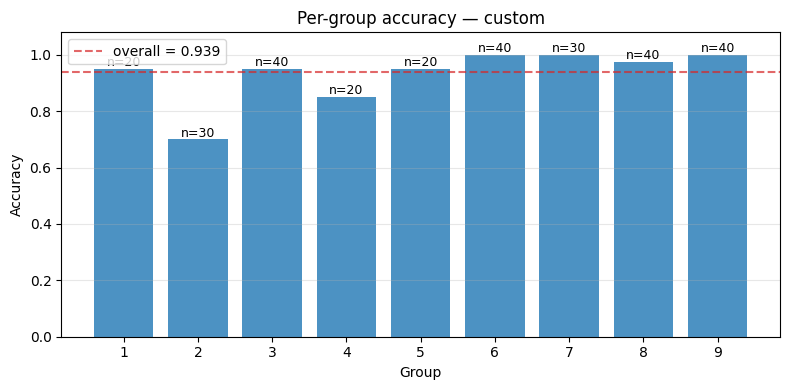

In [13]:
NAME = '256'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(256,), dropout=0.3, activation='relu').to(device)
    train(model, monitor, lr=1e-3, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #3

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(128,)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.971   macro-F1=0.971
      custom:  accuracy=0.911   macro-F1=0.910


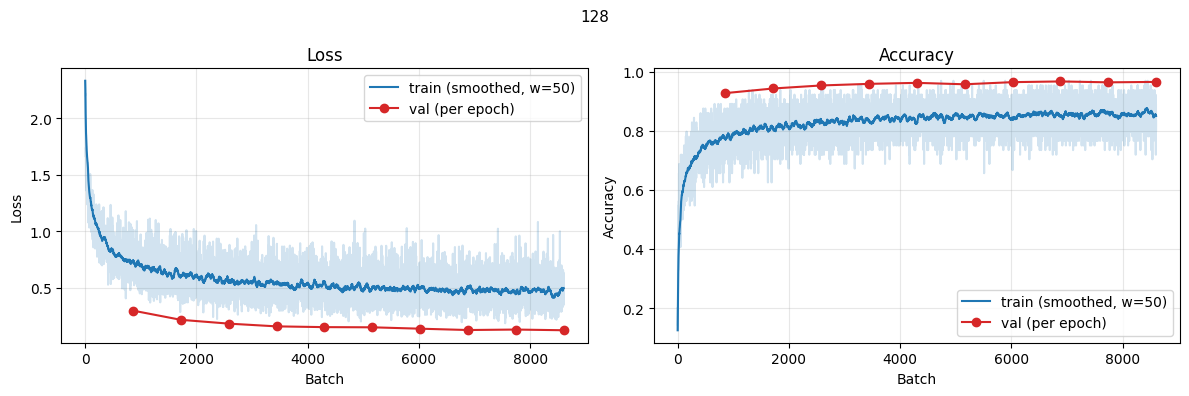

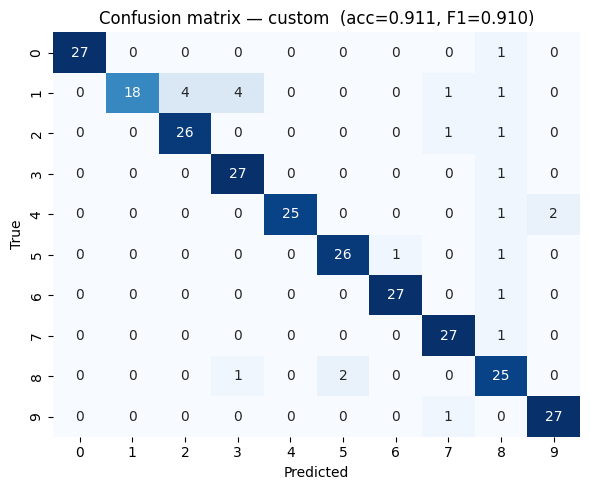

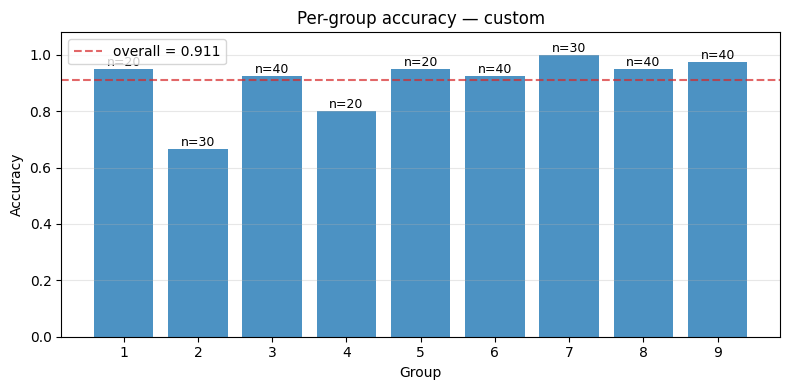

In [14]:
NAME = '128'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(128,), dropout=0.3, activation='relu').to(device)
    train(model, monitor, lr=1e-3, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #4

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(64, 64)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.966   macro-F1=0.966
      custom:  accuracy=0.893   macro-F1=0.895


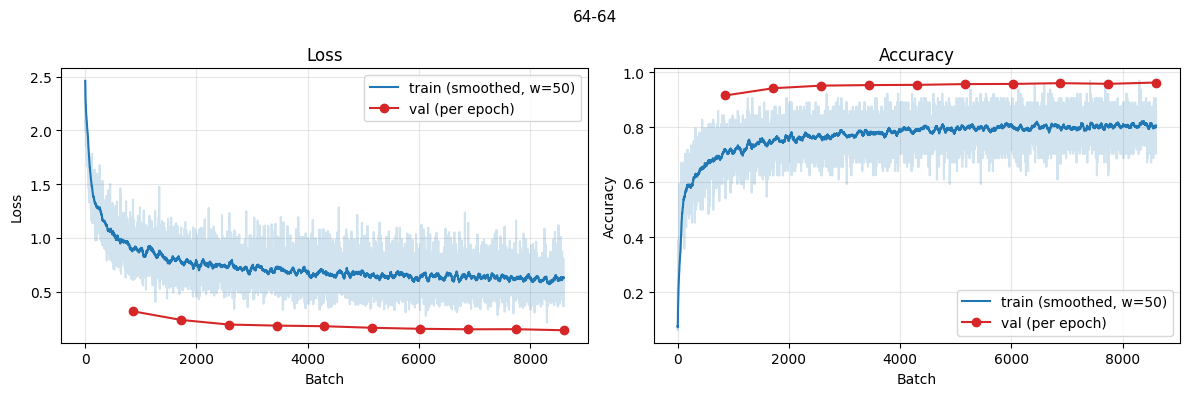

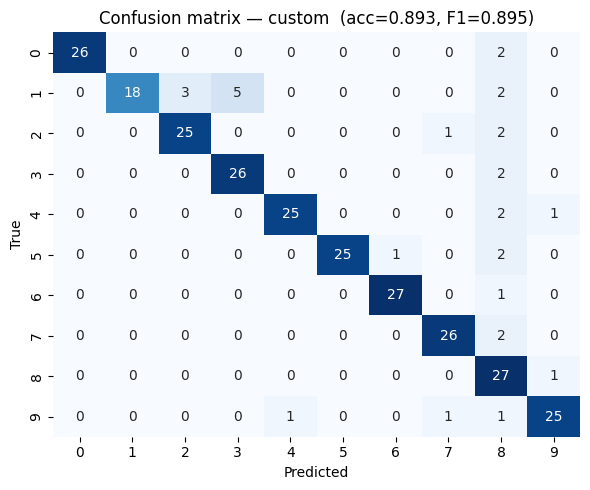

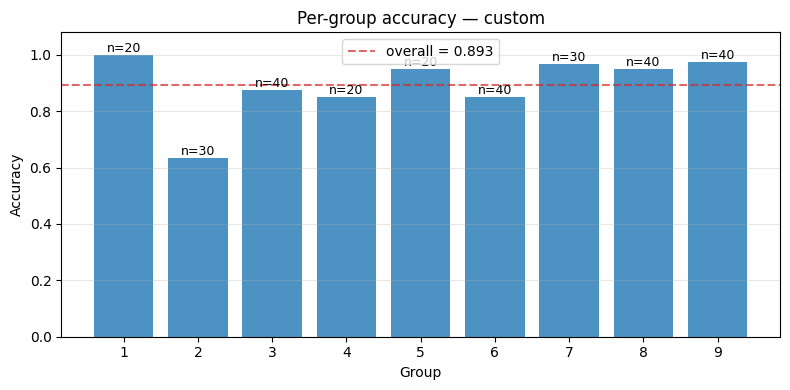

In [15]:
NAME = '64-64'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(64, 64), dropout=0.3, activation='relu').to(device)
    train(model, monitor, lr=1e-3, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #5

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(32, 32, 32, 32)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.934   macro-F1=0.933
      custom:  accuracy=0.818   macro-F1=0.821


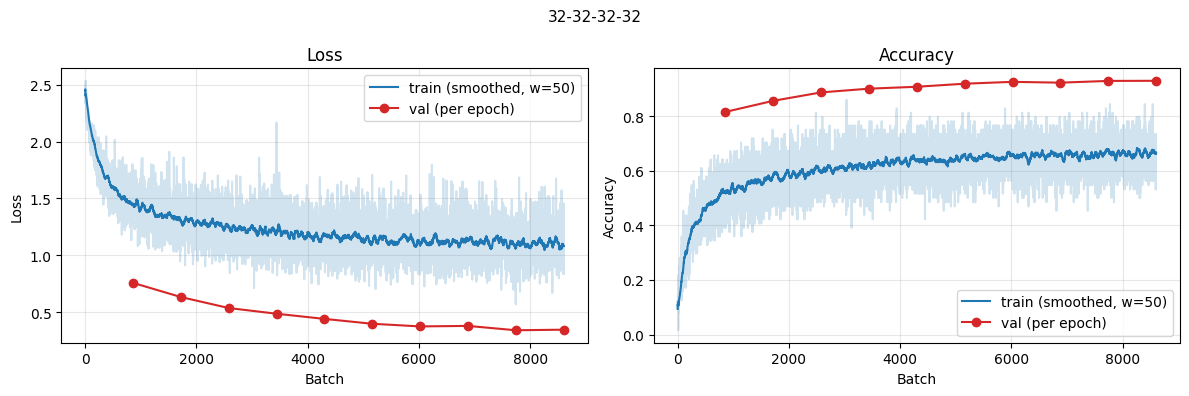

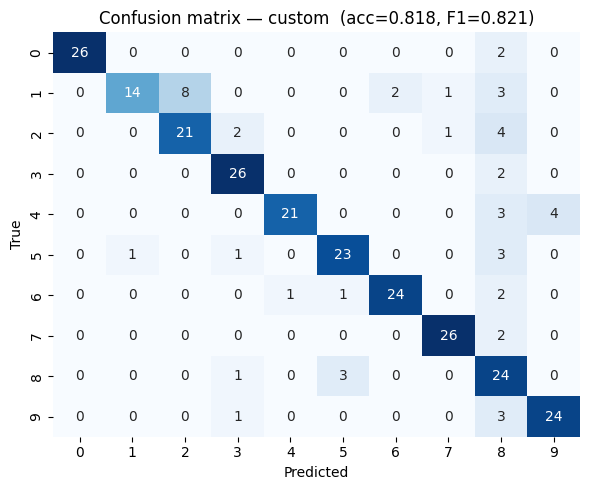

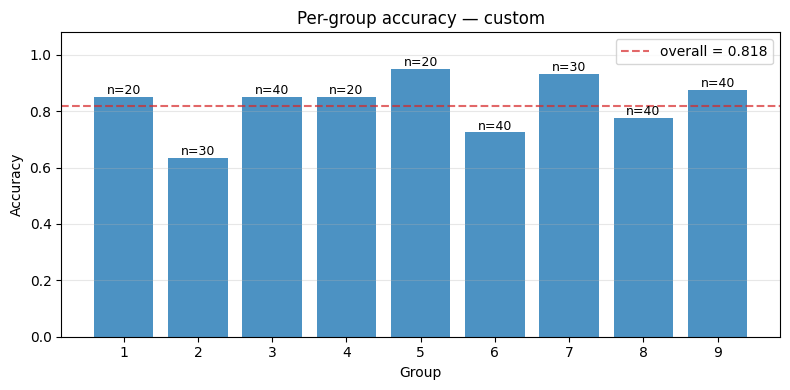

In [16]:
NAME = '32-32-32-32'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(32, 32, 32, 32)).to(device)
    train(model, monitor, lr=0.001, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #6

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(256, 256)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.983   macro-F1=0.983
      custom:  accuracy=0.914   macro-F1=0.918


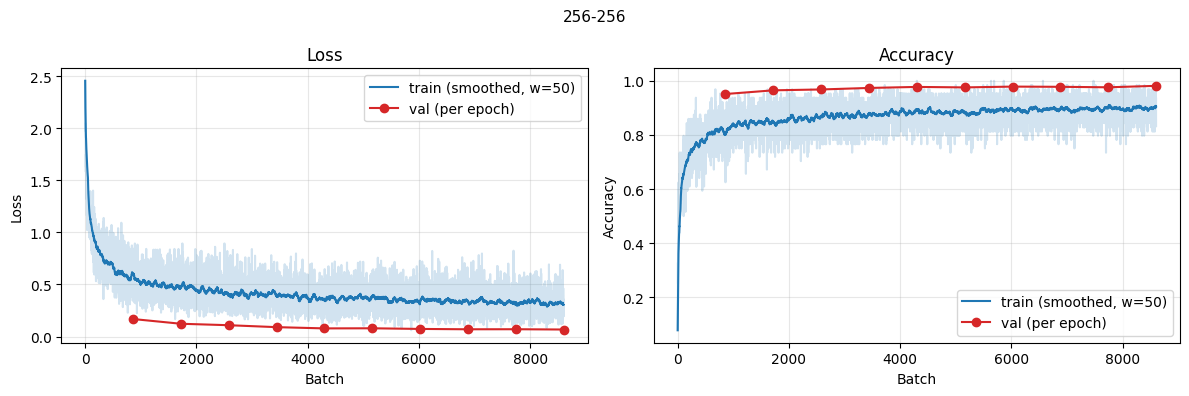

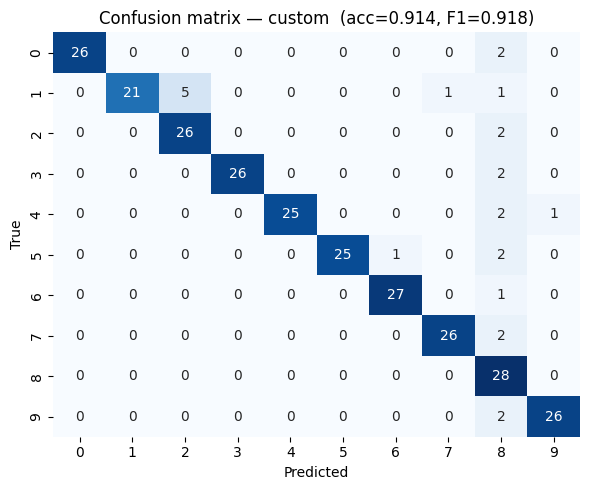

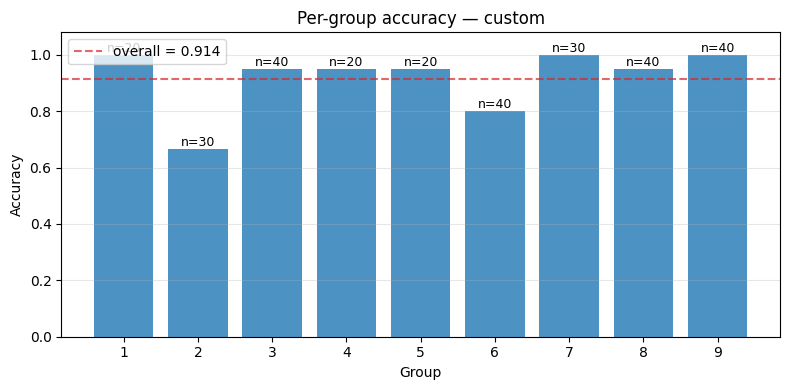

In [17]:
NAME = '256-256'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(256, 256)).to(device)
    train(model, monitor, lr=0.001, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #7

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(512,)` | 0.3 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.979   macro-F1=0.979
      custom:  accuracy=0.921   macro-F1=0.922


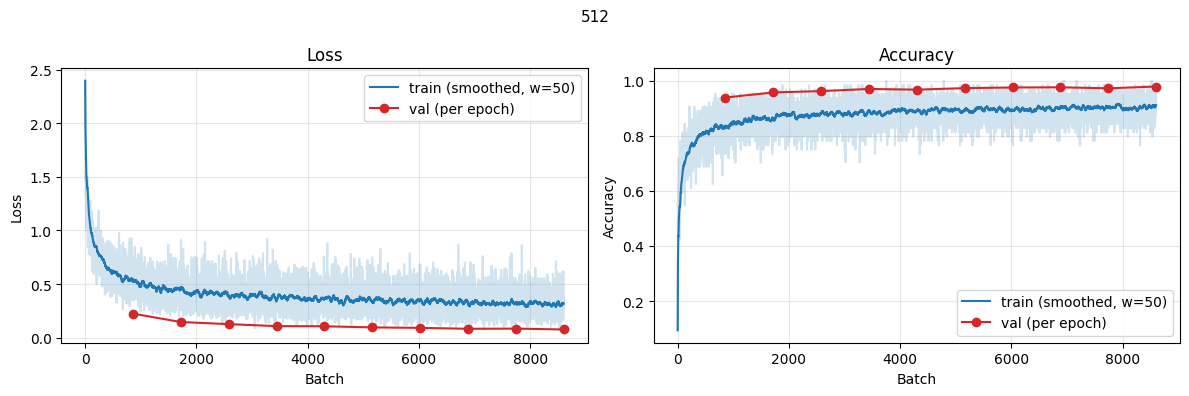

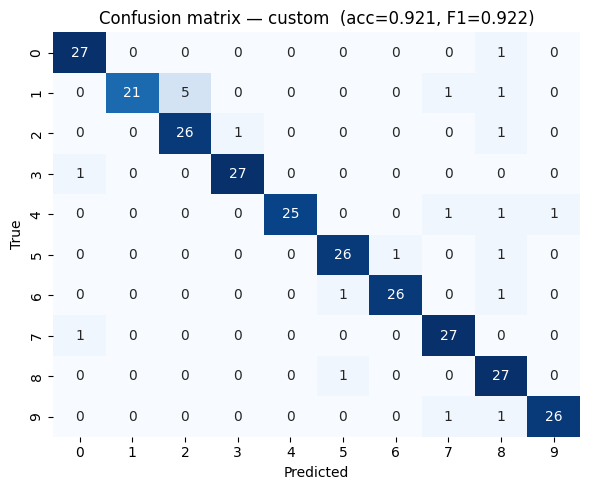

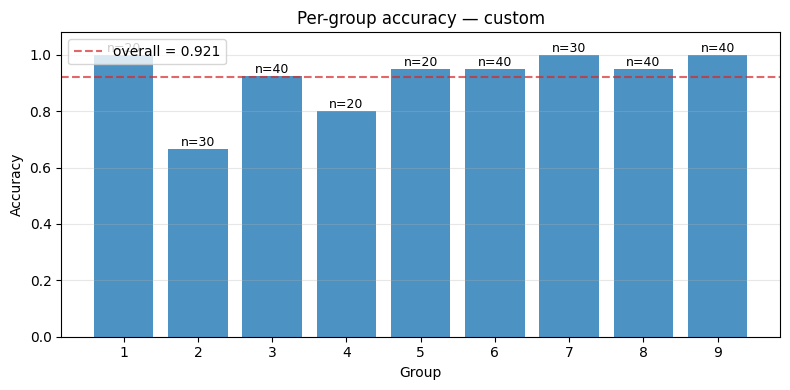

In [18]:
NAME = '512'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(512,)).to(device)
    train(model, monitor, lr=0.001, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #8

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(256,)` | 0.5 | relu | 1e-3 | 10 |


Final metrics:
  mnist_test:  accuracy=0.974   macro-F1=0.974
      custom:  accuracy=0.921   macro-F1=0.922


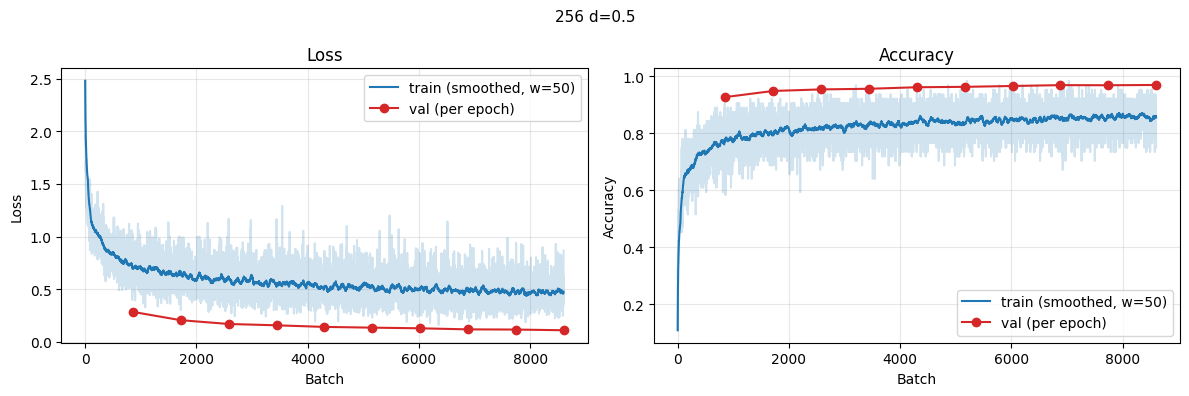

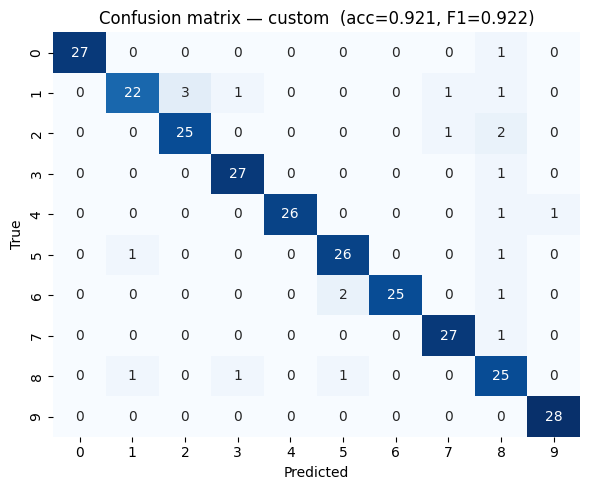

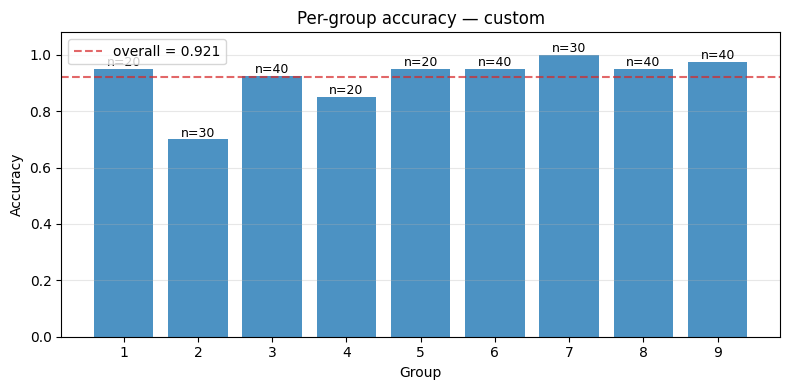

In [19]:
NAME = '256 d=0.5'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(256,), dropout=0.5).to(device)
    train(model, monitor, lr=0.001, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


### Experiment #9

| hidden_sizes | dropout | activation | lr | epochs |
|---|---|---|---|---|
| `(256, 128)` | 0.3 | relu | 5e-4 | 10 |


Final metrics:
  mnist_test:  accuracy=0.981   macro-F1=0.981
      custom:  accuracy=0.900   macro-F1=0.904


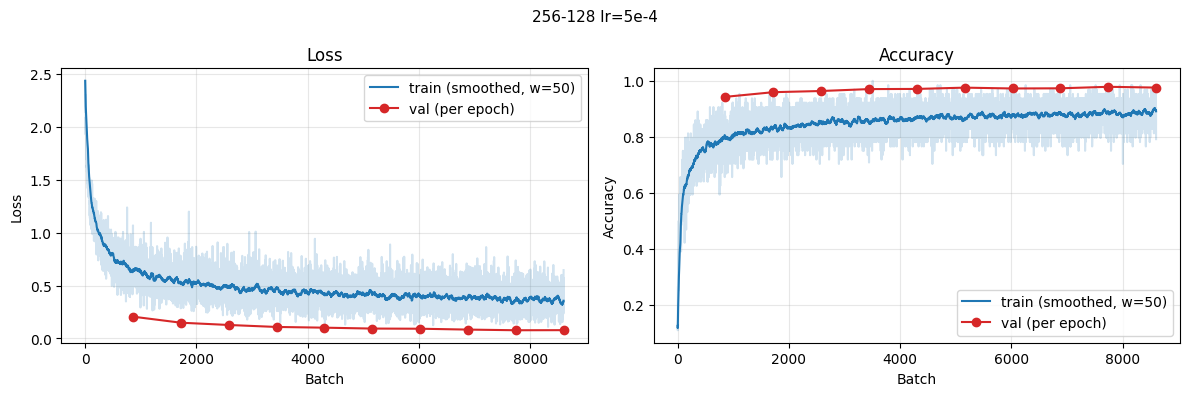

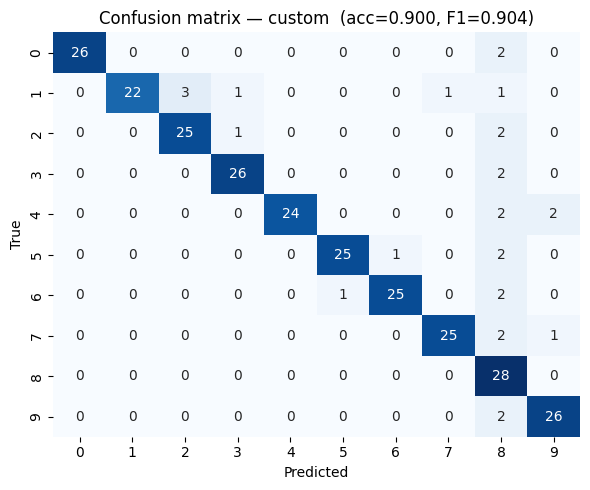

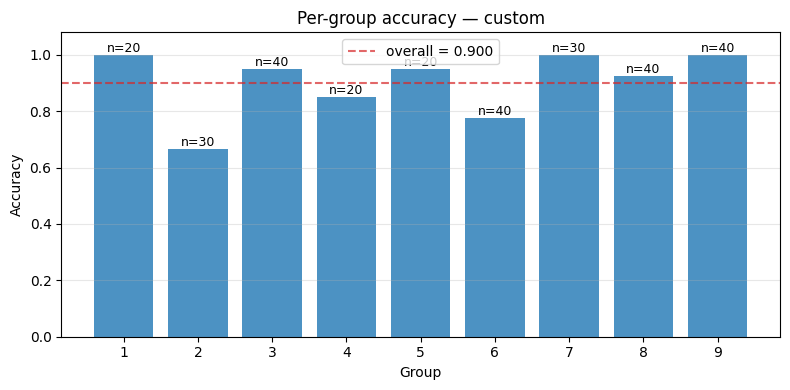

In [20]:
NAME = '256-128 lr=5e-4'
if NAME not in monitors:
    torch.manual_seed(SEED)
    monitor = TrainingMonitor(name=NAME)
    model   = DigitMLP(hidden_sizes=(256, 128)).to(device)
    train(model, monitor, lr=5e-4, epochs=10)
    validate(model, monitor)
    monitors[monitor.name] = monitor
monitors[NAME].plt()


## Comparison

Aggregates every monitor that's been registered into `monitors`. Re-run this cell after adding or re-running an experiment to refresh.


,name,mnist_acc,custom_acc,custom_f1,worst_group
0,256,0.975,0.939,0.940,0.700
1,256 d=0.5,0.974,0.921,0.922,0.700
2,512,0.979,0.921,0.922,0.667
3,256-256,0.983,0.914,0.918,0.667
4,128,0.971,0.911,0.910,0.667
5,256-128 lr=5e-4,0.981,0.900,0.904,0.667
6,256-128,0.981,0.896,0.902,0.667
7,64-64,0.966,0.893,0.895,0.633
8,32-32-32-32,0.934,0.818,0.821,0.633


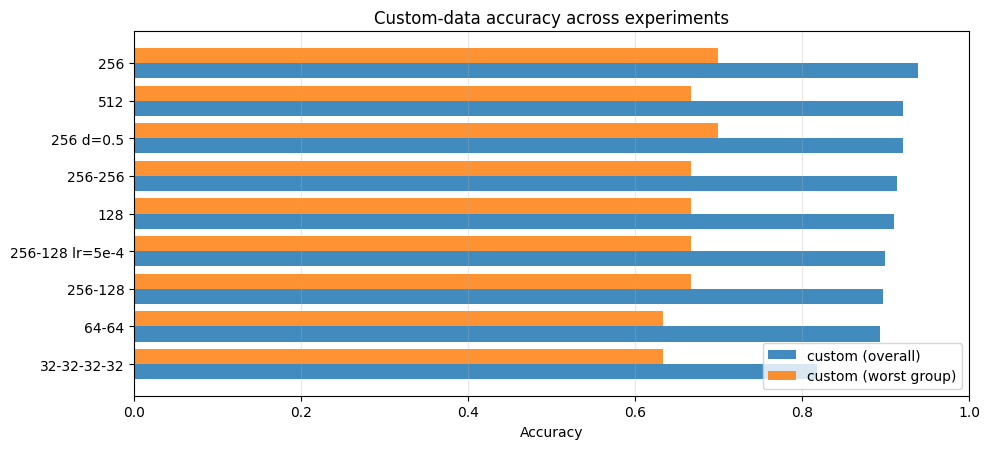

In [21]:
def _summarize(monitors):
    rows = []
    for name, m in monitors.items():
        mnist  = m.evals.get('mnist_test', {})
        custom = m.evals.get('custom', {})
        worst_group = None
        if custom.get('groups') is not None:
            mask = custom['y_true'] == custom['y_pred']
            df = pd.DataFrame({'group': custom['groups'], 'correct': mask})
            per_group = df.groupby('group')['correct'].mean()
            worst_group = per_group.min()
        rows.append({
            'name':        name,
            'mnist_acc':   mnist.get('accuracy'),
            'custom_acc':  custom.get('accuracy'),
            'custom_f1':   custom.get('macro_f1'),
            'worst_group': worst_group,
        })
    return (pd.DataFrame(rows)
              .sort_values('custom_acc', ascending=False, na_position='last')
              .reset_index(drop=True))


summary = _summarize(monitors)
display(summary.style.format({
    'mnist_acc':   '{:.3f}',
    'custom_acc':  '{:.3f}',
    'custom_f1':   '{:.3f}',
    'worst_group': '{:.3f}',
}).background_gradient(subset=['custom_acc', 'custom_f1', 'worst_group'], cmap='Blues'))

# Side-by-side bar chart: custom acc + worst-group acc per run, ranked by custom acc.
fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(summary) + 1)))
order = summary.sort_values('custom_acc')
y = np.arange(len(order))
ax.barh(y - 0.2, order['custom_acc'],  height=0.4, color='tab:blue',  alpha=0.85, label='custom (overall)')
ax.barh(y + 0.2, order['worst_group'], height=0.4, color='tab:orange', alpha=0.85, label='custom (worst group)')
ax.set_yticks(y)
ax.set_yticklabels(order['name'])
ax.set_xlabel('Accuracy')
ax.set_xlim(min(order[['custom_acc', 'worst_group']].min().min() - 0.05, 0.0), 1.0)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(loc='lower right')
ax.set_title('Custom-data accuracy across experiments')
plt.tight_layout()
plt.show()


## Live classification demo

Pick a model by name from `monitors` and a dataset, then sample a random image. Re-run the cell to roll a new sample.


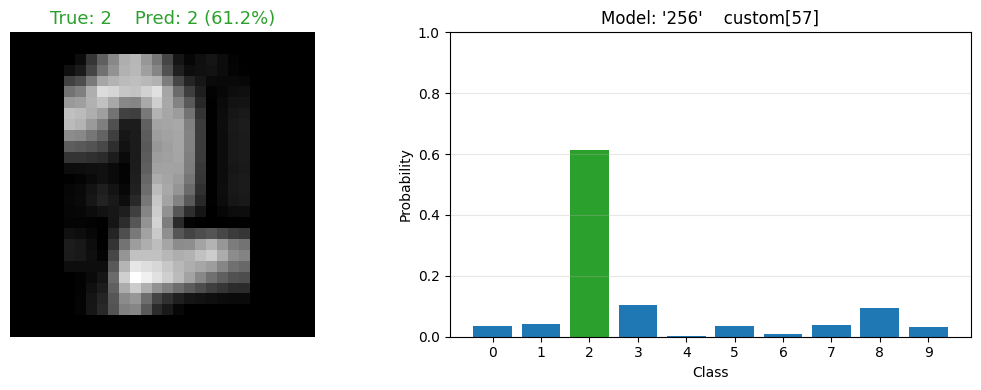

In [48]:
import random

# --- knobs ---
DEMO_MODEL   = '256'             # any key in `monitors`
DEMO_DATASET = custom_dataset    # try mnist_test, train_set, val_set
DEMO_LABEL   = 'custom'          # label used in titles


m = monitors.get(DEMO_MODEL)
if m is None or not hasattr(m, 'model'):
    raise RuntimeError(
        f"Monitor '{DEMO_MODEL}' has no model attached — "
        "re-run the experiment cell to populate it."
    )
model = m.model
model.eval()

idx = random.randrange(len(DEMO_DATASET))
img, true_label = DEMO_DATASET[idx]

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
pred       = int(probs.argmax())
confidence = float(probs[pred])
correct    = pred == true_label

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(img.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title(
    f'True: {true_label}    Pred: {pred} ({confidence:.1%})',
    color='tab:green' if correct else 'tab:red',
    fontsize=13,
)
axes[0].axis('off')

bar_colors = ['tab:blue'] * NUM_CLASSES
bar_colors[pred] = 'tab:green' if correct else 'tab:red'
axes[1].bar(range(NUM_CLASSES), probs, color=bar_colors)
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Model: '{DEMO_MODEL}'    {DEMO_LABEL}[{idx}]")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
